In [1]:
!git clone https://github.com/quark28/miniml.git
%cd miniml

Cloning into 'miniml'...
remote: Enumerating objects: 350, done.
remote: Counting objects: 100% (146/146), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 350 (delta 94), reused 93 (delta 46), pack-reused 204 (from 1)
Receiving objects: 100% (350/350), 2.47 MiB | 13.95 MiB/s, done.
Resolving deltas: 100% (189/189), done.
/content/miniml


In [2]:
from miniml.tree_based.gradientboostingregressor import GradientBoostingRegression

GRADIENT BOOSTING REGRESSION
Custom MSE : 275.6964
Sklearn MSE: 205.3592
Mean prediction difference: 8.8793


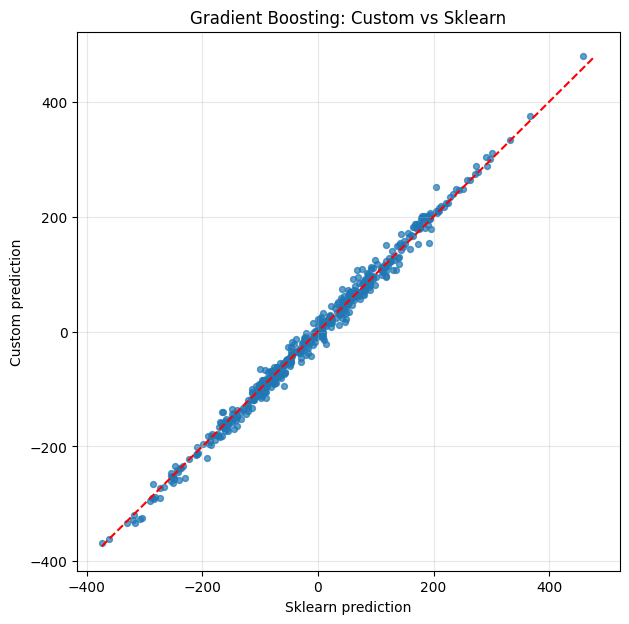

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# ==========================================================
# Генерация данных
# ==========================================================

X, y = make_regression(
    n_samples=500,
    n_features=10,
    n_informative=8,
    noise=15,
    random_state=42
)

# ==========================================================
# Обучение моделей
# ==========================================================

custom_gb = GradientBoostingRegression(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    common_loss_fn='mse',
    random_state=42
).fit(X, y)

sk_gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    loss='squared_error',
    random_state=42
).fit(X, y)

# ==========================================================
# Предсказания
# ==========================================================

pred_custom = custom_gb.predict(X)
pred_sklearn = sk_gb.predict(X)

# ==========================================================
# Метрики
# ==========================================================

mse_custom = mean_squared_error(y, pred_custom)
mse_sklearn = mean_squared_error(y, pred_sklearn)

mae_between = np.mean(np.abs(pred_custom - pred_sklearn))

print("=" * 60)
print("GRADIENT BOOSTING REGRESSION")
print("=" * 60)
print(f"Custom MSE : {mse_custom:.4f}")
print(f"Sklearn MSE: {mse_sklearn:.4f}")
print(f"Mean prediction difference: {mae_between:.4f}")
print("=" * 60)

# ==========================================================
# Визуализация
# ==========================================================

plt.figure(figsize=(7,7))

plt.scatter(
    pred_sklearn,
    pred_custom,
    s=18,
    alpha=0.7
)

lims = [
    min(pred_sklearn.min(), pred_custom.min()),
    max(pred_sklearn.max(), pred_custom.max())
]

plt.plot(lims, lims, 'r--')

plt.xlabel("Sklearn prediction")
plt.ylabel("Custom prediction")
plt.title("Gradient Boosting: Custom vs Sklearn")
plt.grid(alpha=0.3)

plt.show()